In [3]:
import requests
import pandas as pd
from time import sleep
import unidecode 
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LinearRegression
from sklearn.metrics import r2_score
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np

In [4]:
# Statcast Lists
team_ids = [
    108, 109, 110, 111, 112, 113, 114, 115, 116, 117, 118, 119, 120, 121,
    133, 134, 135, 136, 137, 138, 139, 140, 141, 142, 143, 144, 145, 146, 147, 158
]
headers = {'User-Agent': 'Mozilla/5.0 (Windows NT 10.0; Win64; x64) AppleWebKit/537.36 (KHTML, like Gecko) Chrome/58.0.3029.110 Safari/537.3'}

# Master DataFrames
all_standard = []
all_statcast = []

# Statcast features and betas
hit_features = ['Whiff %','Batted Balls','Hard Hit %','Exit Velocity','XBA','Zone Contact %','Chase %', 'Zone Swing %', 'Straight %']
walk_features = ['Chase %', 'Batted Balls', 'Pitches', 'Whiff %', 'Zone Swing %', 'Zone Contact %']
bats_features = ['Pitches', 'Batted Balls']
bases_features = ['XSLG','Whiff %','Chase %','Barrel %', 'Hard Hit %', 'Exit Velocity', 'Launch Angle', 'Straight %', 'Batted Balls']

hit_betas = {'Whiff %': .6,'Batted Balls': .8,'Hard Hit %': 1,'Exit Velocity': .7,'XBA': .9,'Zone Contact %': .3,'Chase %': .5, 'Zone Swing %': .2, 'Straight %': .4}
walk_betas = {'Chase %': .5, 'Batted Balls': 1, 'Pitches': .8, 'Whiff %': .5, 'Zone Swing %': .1, 'Zone Contact %': .2}
bats_betas = {'Pitches': .3, 'Batted Balls': .7}
bases_betas = {'XSLG': .9,'Whiff %': .5,'Chase %': .5,'Barrel %': 1, 'Hard Hit %': .8, 'Exit Velocity': .7, 'Launch Angle': .3, 'Straight %': .4, 'Batted Balls': .3}

unwanted = ['Unnamed: 1_level_0', 'Unnamed: 0_level_0', 'Statcast', 'Standard Stats','Unnamed: 26_level_1']

# Remove rows where 'Player' contains 'MLB' or any team name/nickname
team_nicknames = [
    'D-Backs', 'Braves', 'Orioles', 'Red Sox', 'Cubs', 'White Sox', 'Reds', 'Guardians',
    'Rockies', 'Tigers', 'Astros', 'Royals', 'Angels', 'Dodgers', 'Marlins', 'Brewers',
    'Twins', 'Yankees', 'Athletics', 'Phillies', 'Pirates', 'Padres', 'Giants', 'Mariners',
    'Cardinals', 'Rays', 'Rangers', 'Blue Jays', 'Nationals', 'Mets'
]

#_______________________________________________________________________________________________________________________________________________________________________________________

# Sprinting Dictionary
final_merged_df = pd.DataFrame()

team_info = {
    108: "la-angels", 109: "arizona", 144: "atlanta", 110: "baltimore", 111: "boston",
    112: "chi-cubs", 113: "cincinnati", 114: "cleveland", 115: "colorado", 116: "detroit",
    117: "houston", 118: "kansas-city", 119: "la-dodgers", 121: "miami", 133: "milwaukee",
    134: "minnesota", 121: "ny-mets", 147: "ny-yankees", 133: "oakland", 143: "philadelphia",
    134: "pittsburgh", 135: "san-diego", 136: "seattle", 137: "san-francisco", 138: "st-louis", 139: "tampa-bay", 140: "texas",
    141: "toronto", 120: "washington"
}
#__________________________________________________________________________________________________________________________________________________________________________________

# Regression mappings
regression_targets = {
    'Hit_Score': 'H',
    'Walk_Score': 'BB',
    'Bats_Score': 'AB',
    'Bases_Score': 'TB',
    'Sprint Speed (ft/s)': 'SB'
}

In [5]:
def clean_column(col):
    for u in unwanted:
        col = col.replace(u, '').strip()
    col = ' '.join(col.split())
    return col

def compute_statcast_score(df, features, betas):
    return sum(df[feat] * betas[feat] for feat in features)

In [6]:
for team_id, yah_abbr in team_info.items():
    if team_id not in team_ids:
        continue  # maintain original filtering

    print(f"Processing: {yah_abbr.upper()}")

    # ---------- Statcast scraping ----------
    url_sav = f"https://baseballsavant.mlb.com/team/{team_id}?view=statcast&nav=hitting&season=2024"
    try:
        response = requests.get(url_sav, headers=headers)
        tables = pd.read_html(response.text)
        if len(tables) < 3:
            print(f"{yah_abbr}: Not enough Statcast tables.")
            continue

        standard, statcast1, statcast2 = tables[:3]

        for df in [standard, statcast1, statcast2]:
            df.columns = [clean_column(' '.join(col).strip() if isinstance(col, tuple) else str(col)) for col in df.columns]

        # Drop irrelevant columns
        statcast1.drop(columns=[c for c in ['Season','Pitches'] if c in statcast1.columns], inplace=True, errors='ignore')
        statcast2.drop(columns=[c for c in ['Season','Barrel %'] if c in statcast2.columns], inplace=True, errors='ignore')
        statcast3 = standard.drop(columns=[c for c in ['Season','AB','H','2B','3B','HR','BB','PA','SO','BA','OBP','SLG','WOBA','WOBACON'] if c in standard.columns], errors='ignore')
        standard.drop(columns=[c for c in ['Season','PA','SO','BA','OBP','SLG','WOBA','WOBACON','Pitches','Batted Balls','Barrels','Barrel %','Hard Hit %','Exit Velocity','Launch Angle','XBA','XSLG','XWOBA','XWOBACON'] if c in standard.columns], inplace=True, errors='ignore')

        player_col = [col for col in statcast3.columns if 'Player' in col][0]
        statcast3.rename(columns={player_col: 'Player'}, inplace=True)

        statcast = pd.merge(statcast1, statcast2, on='Player')
        statcast = pd.merge(statcast, statcast3, on='Player')

        for col in ['2B', '3B', 'HR', 'H', 'AB', 'BB']:
            if col not in standard.columns:
                standard[col] = 0

        standard['TB'] = (standard['2B']*2 + standard['3B']*3 + standard['HR']*4 + (standard['H'] - standard['2B'] - standard['3B'] - standard['HR']))
        standard['Runs'] = ((standard['H'] + standard['BB']) * standard['TB']) / (standard['AB'] + standard['BB'])
        standard['Runs'] = standard['Runs'].round()
        standard['TeamID'] = team_id
        statcast['TeamID'] = team_id

        # Scale and score
        all_features = list(set(hit_features + walk_features + bats_features + bases_features))
        missing = [f for f in all_features if f not in statcast.columns]
        if missing:
            print(f"{yah_abbr}: Missing columns: {missing}")
            continue

        scaler = StandardScaler()
        statcast_scaled = statcast.copy()
        statcast_scaled[all_features] = scaler.fit_transform(statcast[all_features])

        statcast['Hit_Score']   = compute_statcast_score(statcast_scaled, hit_features, hit_betas).round(3)
        statcast['Walk_Score']  = compute_statcast_score(statcast_scaled, walk_features, walk_betas).round(3)
        statcast['Bats_Score']  = compute_statcast_score(statcast_scaled, bats_features, bats_betas).round(3)
        statcast['Bases_Score'] = compute_statcast_score(statcast_scaled, bases_features, bases_betas).round(3)

        # Merge standard and statcast on Player
        if 'Player' in standard.columns and 'Player' in statcast.columns:
            combined = pd.merge(statcast, standard, on=['Player', 'TeamID'], how='inner')
            all_statcast.append(combined)
        else:
            print(f"{yah_abbr}: Missing 'Player' or 'TeamID' in merge.")

    except Exception as e:
        print(f"{yah_abbr}: Statcast error - {e}")
        continue

    # ---------- Sprinting/Yahoo merge ----------
    try:
        tables_sav = pd.read_html(response.text)
        if len(tables_sav) < 7:
            print(f"{yah_abbr}: Sprinting table missing.")
            continue

        sprinting = tables_sav[6]
        tables_yah = pd.read_html(f"https://sports.yahoo.com/mlb/teams/{yah_abbr}/stats/")
        if not tables_yah:
            print(f"{yah_abbr}: Yahoo stats missing.")
            continue

        SB = tables_yah[0]
        merged_rows = []

        for _, sprint_row in sprinting.iterrows():
            matching = SB[SB['Player'] == sprint_row['Player']]
            if not matching.empty:
                combined = pd.concat([sprint_row, matching.iloc[0].drop('Player')])
                merged_rows.append(combined)

        if merged_rows:
            merged_df = pd.DataFrame(merged_rows)
            merged_df["Team"] = yah_abbr.upper()
            to_drop = ['Age', 'Pos Rank', 'Age Rank', 'G', 'AB', 'R', 'H', '2B', '3B', 'HR', 'RBI', 'BB', 'K', 'AVG', 'OBP', 'SLG', 'OPS']
            merged_df.drop(columns=[c for c in to_drop if c in merged_df.columns], inplace=True, errors='ignore')
            final_merged_df = pd.concat([final_merged_df, merged_df], ignore_index=True)

        sleep(1)

    except Exception as e:
        print(f"{yah_abbr}: Sprint/Yahoo error - {e}")


Processing: LA-ANGELS


C:\Users\nncg7\AppData\Local\Temp\ipykernel_36080\1586377046.py:11: FutureWarning: Passing literal html to 'read_html' is deprecated and will be removed in a future version. To read from a literal string, wrap it in a 'StringIO' object.
  tables = pd.read_html(response.text)
C:\Users\nncg7\AppData\Local\Temp\ipykernel_36080\1586377046.py:72: FutureWarning: Passing literal html to 'read_html' is deprecated and will be removed in a future version. To read from a literal string, wrap it in a 'StringIO' object.
  tables_sav = pd.read_html(response.text)


Processing: ARIZONA


C:\Users\nncg7\AppData\Local\Temp\ipykernel_36080\1586377046.py:11: FutureWarning: Passing literal html to 'read_html' is deprecated and will be removed in a future version. To read from a literal string, wrap it in a 'StringIO' object.
  tables = pd.read_html(response.text)
C:\Users\nncg7\AppData\Local\Temp\ipykernel_36080\1586377046.py:72: FutureWarning: Passing literal html to 'read_html' is deprecated and will be removed in a future version. To read from a literal string, wrap it in a 'StringIO' object.
  tables_sav = pd.read_html(response.text)


Processing: ATLANTA


...

C:\Users\nncg7\AppData\Local\Temp\ipykernel_36080\1586377046.py:11: FutureWarning: Passing literal html to 'read_html' is deprecated and will be removed in a future version. To read from a literal string, wrap it in a 'StringIO' object.
  tables = pd.read_html(response.text)
C:\Users\nncg7\AppData\Local\Temp\ipykernel_36080\1586377046.py:72: FutureWarning: Passing literal html to 'read_html' is deprecated and will be removed in a future version. To read from a literal string, wrap it in a 'StringIO' object.
  tables_sav = pd.read_html(response.text)


Processing: TORONTO


C:\Users\nncg7\AppData\Local\Temp\ipykernel_36080\1586377046.py:11: FutureWarning: Passing literal html to 'read_html' is deprecated and will be removed in a future version. To read from a literal string, wrap it in a 'StringIO' object.
  tables = pd.read_html(response.text)
C:\Users\nncg7\AppData\Local\Temp\ipykernel_36080\1586377046.py:72: FutureWarning: Passing literal html to 'read_html' is deprecated and will be removed in a future version. To read from a literal string, wrap it in a 'StringIO' object.
  tables_sav = pd.read_html(response.text)


Processing: WASHINGTON


C:\Users\nncg7\AppData\Local\Temp\ipykernel_36080\1586377046.py:11: FutureWarning: Passing literal html to 'read_html' is deprecated and will be removed in a future version. To read from a literal string, wrap it in a 'StringIO' object.
  tables = pd.read_html(response.text)
C:\Users\nncg7\AppData\Local\Temp\ipykernel_36080\1586377046.py:72: FutureWarning: Passing literal html to 'read_html' is deprecated and will be removed in a future version. To read from a literal string, wrap it in a 'StringIO' object.
  tables_sav = pd.read_html(response.text)


In [7]:
df_statcast_all = pd.concat(all_statcast, ignore_index=True)

# Filter out team rows
pattern = r'MLB|' + '|'.join(team_nicknames)
df_statcast_all = df_statcast_all[~df_statcast_all['Player'].str.contains(pattern, case=False, na=False)]

In [8]:
def flip_name(name):
    parts = name.split(',')
    if len(parts) == 2:
        return parts[1].strip() + ' ' + parts[0].strip()
    return name.strip()

df_statcast_all['Player'] = df_statcast_all['Player'].apply(flip_name)

In [9]:
# Ensure consistent formatting in player names (strip whitespace and lowercase if needed)
df_statcast_all['Player'] = df_statcast_all['Player'].str.strip()
final_merged_df['Player'] = final_merged_df['Player'].str.strip()

# Perform inner join on Player name (only keep matching players)
merged_df = pd.merge(df_statcast_all, final_merged_df, on='Player', how='inner')

In [10]:
# Save to new file
merged_df.to_csv('Creating Equations.csv', index=False)

In [11]:
sns.set(style='whitegrid')

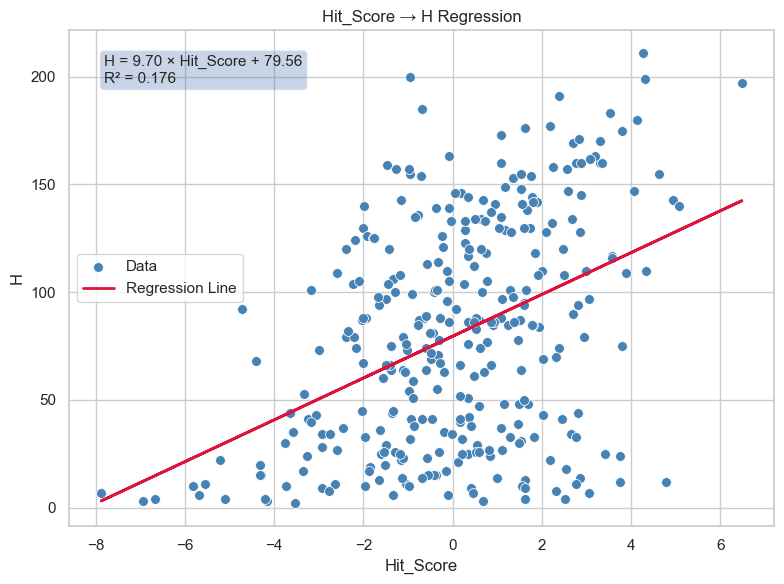

In [12]:
# HIT SCORE → H

# Make the y-intercept close to zero by making no negative inputs


if 'Hit_Score' in merged_df.columns and 'H' in merged_df.columns:
    df = merged_df[['Hit_Score', 'H']].dropna()
    if not df.empty:
        X = df[['Hit_Score']]
        y = df['H']
        model = LinearRegression()
        model.fit(X, y)
        y_pred = model.predict(X)
        r2 = r2_score(y, y_pred)
        plt.figure(figsize=(8, 6))
        sns.scatterplot(x=X['Hit_Score'], y=y, color='steelblue', s=50, label='Data')
        plt.plot(X['Hit_Score'], y_pred, color='crimson', linewidth=2, label='Regression Line')
        plt.text(0.05, 0.95, f"H = {model.coef_[0]:.2f} × Hit_Score + {model.intercept_:.2f}\nR² = {r2:.3f}",
                 transform=plt.gca().transAxes, fontsize=11, verticalalignment='top',
                 bbox=dict(boxstyle='round', alpha=0.3))
        plt.title("Hit_Score → H Regression")
        plt.xlabel("Hit_Score")
        plt.ylabel("H")
        plt.legend()
        plt.tight_layout()
        plt.show()


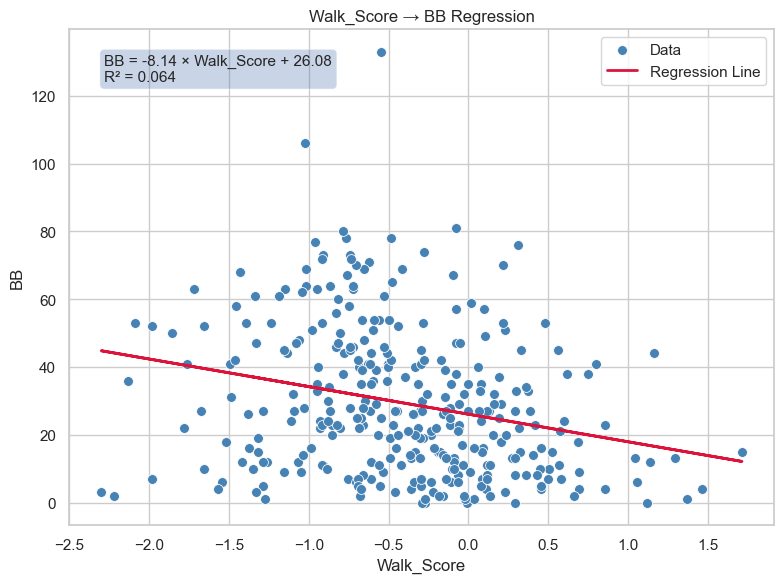

In [13]:
# WALK SCORE → BB

# I rather the scores graph look more like a linear curve, so adjust the equation to eventually look like that


if 'Walk_Score' in merged_df.columns and 'BB' in merged_df.columns:
    df = merged_df[['Walk_Score', 'BB']].dropna()
    if not df.empty:
        X = df[['Walk_Score']]
        y = df['BB']
        model = LinearRegression()
        model.fit(X, y)
        y_pred = model.predict(X)
        r2 = r2_score(y, y_pred)
        plt.figure(figsize=(8, 6))
        sns.scatterplot(x=X['Walk_Score'], y=y, color='steelblue', s=50, label='Data')
        plt.plot(X['Walk_Score'], y_pred, color='crimson', linewidth=2, label='Regression Line')
        plt.text(0.05, 0.95, f"BB = {model.coef_[0]:.2f} × Walk_Score + {model.intercept_:.2f}\nR² = {r2:.3f}",
                 transform=plt.gca().transAxes, fontsize=11, verticalalignment='top',
                 bbox=dict(boxstyle='round', alpha=0.3))
        plt.title("Walk_Score → BB Regression")
        plt.xlabel("Walk_Score")
        plt.ylabel("BB")
        plt.legend()
        plt.tight_layout()
        plt.show()


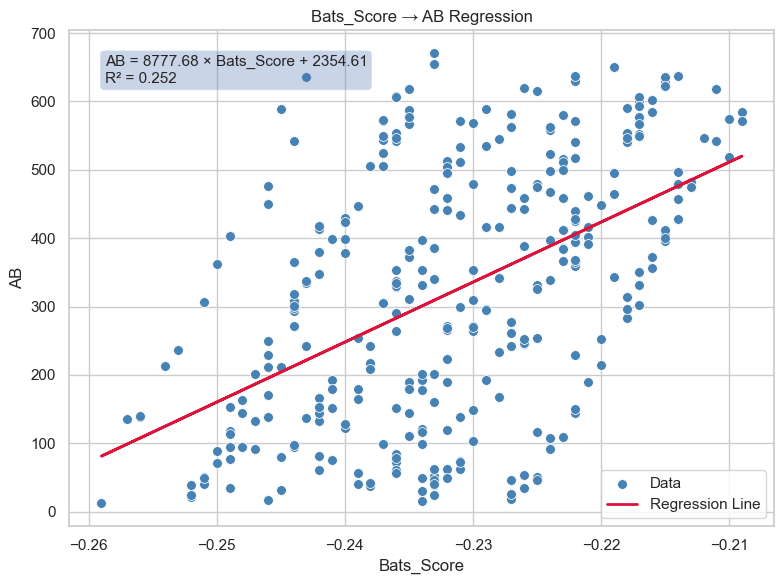

In [14]:
# BATS SCORE → AB

# Adjust the scores so that the graph looks like it has a curve


if 'Bats_Score' in merged_df.columns and 'AB' in merged_df.columns:
    df = merged_df[['Bats_Score', 'AB']].dropna()
    if not df.empty:
        X = df[['Bats_Score']]
        y = df['AB']
        model = LinearRegression()
        model.fit(X, y)
        y_pred = model.predict(X)
        r2 = r2_score(y, y_pred)
        plt.figure(figsize=(8, 6))
        sns.scatterplot(x=X['Bats_Score'], y=y, color='steelblue', s=50, label='Data')
        plt.plot(X['Bats_Score'], y_pred, color='crimson', linewidth=2, label='Regression Line')
        plt.text(0.05, 0.95, f"AB = {model.coef_[0]:.2f} × Bats_Score + {model.intercept_:.2f}\nR² = {r2:.3f}",
                 transform=plt.gca().transAxes, fontsize=11, verticalalignment='top',
                 bbox=dict(boxstyle='round', alpha=0.3))
        plt.title("Bats_Score → AB Regression")
        plt.xlabel("Bats_Score")
        plt.ylabel("AB")
        plt.legend()
        plt.tight_layout()
        plt.show()


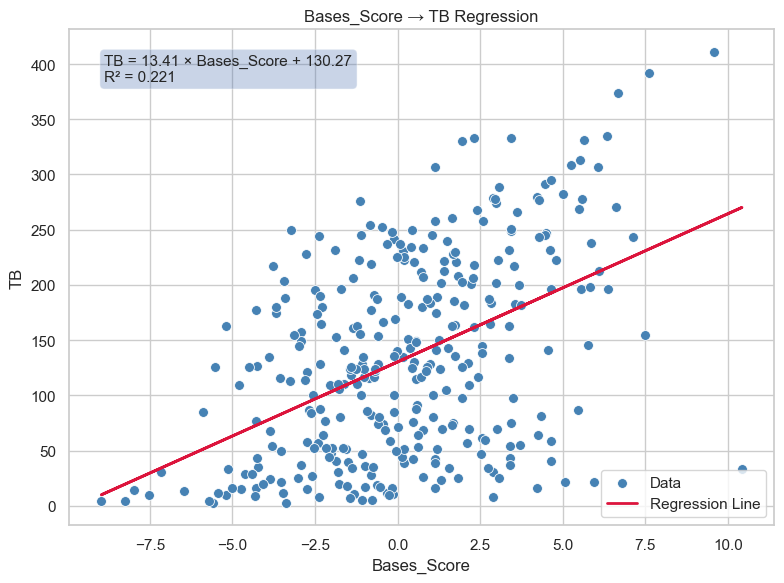

In [15]:
# BASES SCORE → TB

# Make the scores all Positive so that the y intercept makes sense at a starting value

if 'Bases_Score' in merged_df.columns and 'TB' in merged_df.columns:
    df = merged_df[['Bases_Score', 'TB']].dropna()
    if not df.empty:
        X = df[['Bases_Score']]
        y = df['TB']
        model = LinearRegression()
        model.fit(X, y)
        y_pred = model.predict(X)
        r2 = r2_score(y, y_pred)
        plt.figure(figsize=(8, 6))
        sns.scatterplot(x=X['Bases_Score'], y=y, color='steelblue', s=50, label='Data')
        plt.plot(X['Bases_Score'], y_pred, color='crimson', linewidth=2, label='Regression Line')
        plt.text(0.05, 0.95, f"TB = {model.coef_[0]:.2f} × Bases_Score + {model.intercept_:.2f}\nR² = {r2:.3f}",
                 transform=plt.gca().transAxes, fontsize=11, verticalalignment='top',
                 bbox=dict(boxstyle='round', alpha=0.3))
        plt.title("Bases_Score → TB Regression")
        plt.xlabel("Bases_Score")
        plt.ylabel("TB")
        plt.legend()
        plt.tight_layout()
        plt.show()


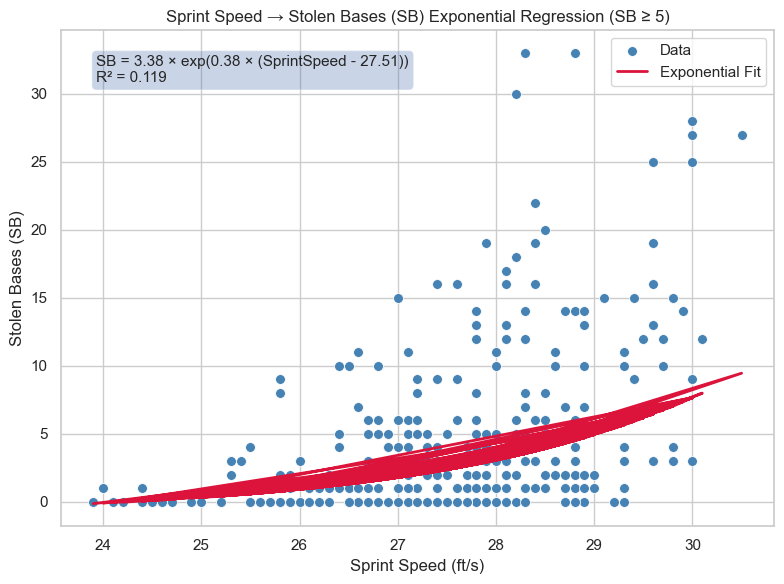

In [17]:
# FT/S -> SB

# The curve looks exponential, but it doesn't reach the "Peak"
# There is a factor that I am missing to make it clearly "exponential"

# Filter players with SB >= 5
df = merged_df[['Sprint Speed (ft/s)', 'SB']].dropna()
df_filtered = df[df['SB'] >= 0]

# Prepare variables
X_orig = df_filtered['Sprint Speed (ft/s)']
x_mean = X_orig.mean()
X_centered = (X_orig - x_mean).to_frame()

# Log1p transform on SB
y_log = np.log1p(df_filtered['SB'])

# Fit linear regression on centered sprint speed
model = LinearRegression()
model.fit(X_centered, y_log)

# Predict and invert log1p
y_log_pred = model.predict(X_centered)
y_pred = np.expm1(y_log_pred)

# Calculate R^2
r2 = r2_score(df_filtered['SB'], y_pred)

# Extract coefficients
A = np.exp(model.intercept_)
b = model.coef_[0]

equation_text = f"SB = {A:.2f} × exp({b:.2f} × (SprintSpeed - {x_mean:.2f}))"
r2_text = f"R² = {r2:.3f}"

# Plot results
plt.figure(figsize=(8, 6))
sns.scatterplot(x=X_orig, y=df_filtered['SB'], color='steelblue', s=50, label='Data')
plt.plot(X_orig, y_pred, color='crimson', linewidth=2, label='Exponential Fit')

plt.text(0.05, 0.95, equation_text + '\n' + r2_text,
         transform=plt.gca().transAxes,
         fontsize=11,
         verticalalignment='top',
         bbox=dict(boxstyle='round', alpha=0.3))

plt.title("Sprint Speed → Stolen Bases (SB) Exponential Regression (SB ≥ 5)")
plt.xlabel("Sprint Speed (ft/s)")
plt.ylabel("Stolen Bases (SB)")
plt.legend()
plt.tight_layout()
plt.show()